In [ ]:
# --- bootstrap: anchor to the repository root, wherever this notebook was opened from ---
# Notebooks live two levels deep under notebooks/, so the cwd-relative path logic below needs the
# root established first. Keyed on pytest.ini, which is not tied to any folder-naming decision.
import os
import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pytest.ini").exists())
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f"repo root: {_root}")

# 11 — News flow and the magnitude of market moves**Author:** Dongxin (NLP/LLM lead) · **Target:** SIADS 699 capstone, Team Alpha Signal

## Context & MethodsNotebooks 05–10 asked whether news sentiment predicts the **direction** of the next session andreturned a null. This notebook establishes *why* that null occurs and tests the hypothesis thatsurvives it.**The alignment problem.** In the existing panel, the news feature for `session_date` d spans`(close d−1, close d]` while the target is `close d → close d+1`. Every event in the feature istherefore already priced at the instant the target return begins. Measured on the raw export, dailymean sentiment correlates **+0.134 (t = 5.2)** with the session it is contemporaneous with and**+0.001 (t = 0.0)** with the next session. The sentiment measure works; it is pointed at a returnthat has already happened.**The re-aligned window.** Every feature below is built from news arriving in`(close d−1, 09:30 d]` — strictly after the last observed price, so it is non-leaky by construction.71% of events arrive outside regular trading hours, so this window is well populated.**The hypothesis.** Market efficiency predicts exactly the pattern above: news *tone* is absorbedinto the price *level* within the session it arrives, but news *arrival* drives realised volatility.So we move the primary target from direction to **magnitude**.**Pre-registered grid.** Specs are fixed before results are read. Every number is out-of-sample(expanding walk-forward, refit monthly) and every lift is tested against a **block permutation null**(circular rotation of the news block, which preserves autocorrelation and seasonality). No in-sampleAUC is reported anywhere in this notebook.**Two references, not one.** The permutation nulls below do *not* centre at 0.5: rotating a
trending feature misaligns it with the volatility regime and pushes the rotated AUC below
chance, so "beats the permutation 95th" is an anti-conservative bar on its own. Every spec is
therefore also given a 95% block-bootstrap CI on its out-of-sample AUC, and only specs clearing
**both** are reported as findings.

**Positive control.** Spec 4 must pass. If the harness cannot recover a known effect, a null
elsewhere carries no information — it is indistinguishable from a broken pipeline.

**Confound control.** Volatility is autocorrelated and so is news flow. Spec 5 therefore tests whethertoday's news adds anything *on top of* trailing volatility **and** trailing news flow — the strictquestion. Reporting Spec 1 without Spec 5 would overstate the finding.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.max_columns = 60

PROJECT_ROOT = Path.cwd()
REPO_ROOT = next((p for p in [PROJECT_ROOT, *PROJECT_ROOT.parents]
                  if (p / "data").is_dir()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Run from the repository root or a subdirectory of it.")
DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
OUT_DIR = REPO_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

# --- pre-registered constants -------------------------------------------------
MARKET_CLOSE_MIN = 16 * 60      # 16:00 ET, end of the prior session
MARKET_OPEN_MIN  = 9 * 60 + 30  # 09:30 ET, first tradeable price of session d
MEDIAN_WINDOW    = 60           # trailing window defining the magnitude label
N_INIT           = 500          # first walk-forward training block (sessions)
REFIT_STEP       = 21           # refit cadence (~1 month)
N_PERM           = 250          # block permutation draws
SEED             = 20260807

rng = np.random.default_rng(SEED)
print(f"Repo root: {REPO_ROOT}")
print(f"News window: (close d-1, 09:30 d]  |  permutation draws: {N_PERM}  |  seed: {SEED}")

Repo root: C:\Users\dongx\OneDrive\文档\Group\siads-699-sentiment-analysis-sp500
News window: (close d-1, 09:30 d]  |  permutation draws: 250  |  seed: 20260807


### 1. Re-aligned news window — RavenPack features`signal_calendar_date` already applies a 16:00 ET cutoff, so events carrying signal date d thatarrived at or after 16:00 ET belong to the evening of d−1, and those before 09:30 ET belong to themorning of d. Both post-date the close of d−1. Events between 09:30 and 15:59 are discarded: theyarrive *during* session d and are priced by its close.

In [2]:
events = pd.read_csv(
    RAW_DIR / "ravenpack_core_events_2015_2026.csv",
    usecols=["timestamp_utc", "signal_calendar_date", "event_sentiment_score"],
)
events["et"] = pd.to_datetime(events["timestamp_utc"], utc=True).dt.tz_convert("America/New_York")
events["scd"] = pd.to_datetime(events["signal_calendar_date"])
events["minute_of_day"] = events["et"].dt.hour * 60 + events["et"].dt.minute

is_pre_open = (events["minute_of_day"] >= MARKET_CLOSE_MIN) | (events["minute_of_day"] < MARKET_OPEN_MIN)
pre_open = events.loc[is_pre_open].copy()

print(f"All events                      : {len(events):,}")
print(f"Pre-open (non-leaky) events     : {len(pre_open):,}  ({is_pre_open.mean():.1%})")
print(f"Discarded as already-priced     : {(~is_pre_open).sum():,}")


def build_news_features(df, score_col, prefix):
    """Session-level aggregates of a per-event sentiment score over the pre-open window."""
    grp = df.groupby("scd")[score_col]
    out = pd.DataFrame({
        f"{prefix}_flow":     np.log1p(grp.size()),   # news ARRIVAL volume
        f"{prefix}_tone":     grp.mean(),             # net tone
        f"{prefix}_net":      grp.sum(),              # tone x volume
        f"{prefix}_disp":     grp.std(),              # disagreement across stories
        f"{prefix}_absmean":  df.assign(_x=df[score_col].abs()).groupby("scd")["_x"].mean(),
        f"{prefix}_tail":     df.assign(_x=df[score_col].abs() > 0.7).groupby("scd")["_x"].mean(),
        f"{prefix}_negshare": df.assign(_x=df[score_col] < -0.3).groupby("scd")["_x"].mean(),
    })
    return out


rp_features = build_news_features(pre_open, "event_sentiment_score", "rp")
print(f"\nRavenPack feature frame: {rp_features.shape[0]:,} sessions x {rp_features.shape[1]} features")
rp_features.head()

All events                      : 403,556
Pre-open (non-leaky) events     : 287,868  (71.3%)
Discarded as already-priced     : 115,688

RavenPack feature frame: 2,177 sessions x 7 features


,rp_flow,rp_tone,rp_net,rp_disp,rp_absmean,rp_tail,rp_negshare
scd,,,,,,,
2020-01-01,2.079442,-0.281429,-1.97,0.476705,0.501429,0.142857,0.714286
2020-01-02,4.779123,0.013475,1.59,0.396548,0.316017,0.042373,0.279661
2020-01-03,5.105945,0.010061,1.65,0.429443,0.382134,0.012195,0.341463
2020-01-04,3.891820,0.050208,2.41,0.438098,0.361042,0.041667,0.270833
2020-01-05,1.791759,-0.194000,-0.97,0.554689,0.514000,0.200000,0.600000


### 1b. The same window, scored by FinBERTThe LLM layer is re-scored on the identical window so that RavenPack and FinBERT are compared onexactly the same events — an apples-to-apples scorer comparison, which is this project's headlineNLP contribution.

In [3]:
fb_scores = pd.read_csv(RAW_DIR / "finbert_scores.csv", usecols=["text_id", "sentiment"])
fb_map = pd.read_csv(
    RAW_DIR / "llm_scoring_event_map.csv",
    usecols=["timestamp_utc", "signal_calendar_date", "text_id"],
)

fb = fb_map.merge(fb_scores, on="text_id", how="inner")
fb["et"] = pd.to_datetime(fb["timestamp_utc"], utc=True).dt.tz_convert("America/New_York")
fb["scd"] = pd.to_datetime(fb["signal_calendar_date"])
fb["minute_of_day"] = fb["et"].dt.hour * 60 + fb["et"].dt.minute
fb_pre = fb.loc[(fb["minute_of_day"] >= MARKET_CLOSE_MIN) | (fb["minute_of_day"] < MARKET_OPEN_MIN)].copy()

fb_features = build_news_features(fb_pre, "sentiment", "fb")
print(f"FinBERT-scored pre-open events : {len(fb_pre):,}")
print(f"FinBERT feature frame          : {fb_features.shape[0]:,} sessions x {fb_features.shape[1]} features")

overlap = rp_features.join(fb_features, how="inner")
print(f"\nSession-level agreement, RavenPack vs FinBERT tone: "
      f"r = {overlap['rp_tone'].corr(overlap['fb_tone']):+.3f}")
print(f"Session-level agreement, flow (identical by construction): "
      f"r = {overlap['rp_flow'].corr(overlap['fb_flow']):+.3f}")

FinBERT-scored pre-open events : 287,868
FinBERT feature frame          : 2,177 sessions x 7 features

Session-level agreement, RavenPack vs FinBERT tone: r = +0.570
Session-level agreement, flow (identical by construction): r = +1.000


### 2. Targets and price-only controls**Magnitude target** (primary): `|r_d|` above its own trailing 60-session median. The threshold usesonly data through d−1, so the label is computable in real time.**Direction target** (contrast): `sign(r_d)`, the question notebooks 05–10 asked, now on there-aligned window.All price controls are lagged by one session.

In [4]:
panel = pd.read_csv(DATA_DIR / "model_daily_panel.csv", parse_dates=["session_date"])
market = panel.pivot_table(index="session_date", columns="ticker", values="daily_return").mean(axis=1)
print(f"Equal-weight market series: {len(market):,} sessions, "
      f"{market.index.min().date()} .. {market.index.max().date()}")

df = pd.DataFrame({"r": market}).join(rp_features, how="left").join(fb_features, how="left")
df["abs_r"] = df["r"].abs()

# --- lagged price / volatility controls ---
df["rev1"]  = df["r"].shift(1)
df["mom5"]  = df["r"].rolling(5).sum().shift(1)
df["vol5"]  = df["r"].rolling(5).std().shift(1)
df["vol20"] = df["r"].rolling(20).std().shift(1)
df["abs_r1"] = df["abs_r"].shift(1)
df["med60"] = df["abs_r"].rolling(MEDIAN_WINDOW).median().shift(1)

# --- lagged NEWS control: the recent normal level of news flow ---
df["flow_ma20"] = df["rp_flow"].rolling(20).mean().shift(1)

# --- targets ---
# NaN > NaN evaluates to False, so `.astype(int)` would silently label the first
# MEDIAN_WINDOW sessions as 0 and dropna could never remove them. Keep them NaN.
df["y_magnitude"] = np.where(df["med60"].notna(), (df["abs_r"] > df["med60"]), np.nan)
df["y_direction"] = np.where(df["r"].notna(), (df["r"] > 0), np.nan)

RP_TONE  = ["rp_tone", "rp_net", "rp_disp", "rp_absmean", "rp_tail", "rp_negshare"]
FB_TONE  = ["fb_tone", "fb_net", "fb_disp", "fb_absmean", "fb_tail", "fb_negshare"]
RP_FLOW  = ["rp_flow"]
VOL_BASE = ["vol20", "vol5", "abs_r1"]
DIR_BASE = ["rev1", "mom5", "vol20"]

assert df["y_magnitude"].isna().sum() == MEDIAN_WINDOW, "magnitude label must be NaN before the window fills"
print(f"Magnitude base rate: {df['y_magnitude'].mean():.3f}   "
      f"Direction base rate: {df['y_direction'].mean():.3f}")
print(f"Sessions with no magnitude label (trailing window not yet full): "
      f"{int(df['y_magnitude'].isna().sum())}")

Equal-weight market series: 1,508 sessions, 2020-01-02 .. 2025-12-31
Magnitude base rate: 0.483   Direction base rate: 0.548
Sessions with no magnitude label (trailing window not yet full): 60


### 3. Evaluation harnessExpanding walk-forward: train on everything up to session *i*, score the next 21 sessionsout-of-sample, advance, repeat. AUC is computed once over the pooled out-of-sample predictions.The permutation null circularly rotates the **news block only** against the return series. Thispreserves the autocorrelation of both series and destroys only their alignment — the correct nullfor a time-series feature. It also exposes baseline artefacts: if the null does not centre nearzero, the baseline itself is doing something and the raw lift cannot be read at face value.

In [5]:
def walk_forward_predictions(frame, feature_cols, y_col):
    """Pooled out-of-sample predictions from an expanding walk-forward, in time order."""
    preds, truth, i = [], [], N_INIT
    while i < len(frame):
        j = min(i + REFIT_STEP, len(frame))
        train, test = frame.iloc[:i], frame.iloc[i:j]
        if train[y_col].nunique() > 1:
            model = make_pipeline(StandardScaler(),
                                  LogisticRegression(C=1.0, max_iter=3000))
            model.fit(train[feature_cols], train[y_col])
            preds.append(model.predict_proba(test[feature_cols])[:, 1])
            truth.append(test[y_col].to_numpy())
        i = j
    return np.concatenate(preds), np.concatenate(truth)


def walk_forward_auc(frame, feature_cols, y_col):
    """Pooled out-of-sample AUC. An empty feature set is a coin flip by definition."""
    if not feature_cols:
        return 0.5
    pred, truth = walk_forward_predictions(frame, feature_cols, y_col)
    return roc_auc_score(truth, pred)


def block_bootstrap_ci(pred, truth, block=REFIT_STEP, n_boot=500, alpha=0.05):
    """Percentile CI for the OOS AUC, resampling contiguous blocks to respect autocorrelation.

    This is reported alongside the permutation p because the permutation nulls in this notebook
    do NOT centre at 0.5 -- rotating a trending feature misaligns it with the volatility regime
    and pushes the rotated AUC below chance. Beating an off-centre null is an anti-conservative
    bar, so the CI against 0.5 is the stricter of the two references. Read both.
    """
    n = len(truth)
    starts = np.arange(0, n, block)
    aucs = []
    for _ in range(n_boot):
        picks = rng.choice(starts, size=len(starts), replace=True)
        idx = np.concatenate([np.arange(s, min(s + block, n)) for s in picks])
        t, p = truth[idx], pred[idx]
        if len(np.unique(t)) > 1:
            aucs.append(roc_auc_score(t, p))
    return float(np.percentile(aucs, 100 * alpha / 2)), float(np.percentile(aucs, 100 * (1 - alpha / 2)))


def evaluate(label, news_cols, base_cols, y_col, n_perm=N_PERM):
    """Out-of-sample lift of `news_cols` over `base_cols`, with a block permutation null."""
    needed = list(dict.fromkeys(news_cols + base_cols + [y_col]))
    frame = df.dropna(subset=needed).reset_index(drop=True)

    auc_base = walk_forward_auc(frame, base_cols, y_col)
    pred, truth = walk_forward_predictions(frame, base_cols + news_cols, y_col)
    auc_full = roc_auc_score(truth, pred)
    observed = auc_full - auc_base
    ci_low, ci_high = block_bootstrap_ci(pred, truth)

    null = np.empty(n_perm)
    for k in range(n_perm):
        shift = rng.integers(30, len(frame) - 30)
        rotated = frame.copy()
        rotated[news_cols] = np.roll(frame[news_cols].to_numpy(), shift, axis=0)
        null[k] = walk_forward_auc(rotated, base_cols + news_cols, y_col) - auc_base

    p_value = float((null >= observed).mean())
    return {
        "spec": label, "n_oos": len(truth), "target": y_col,
        "auc_baseline": auc_base, "auc_with_news": auc_full, "lift": observed,
        "auc_ci_low": ci_low, "auc_ci_high": ci_high, "beats_half": ci_low > 0.5,
        "null_mean": null.mean(), "null_p95": np.percentile(null, 95),
        "p_value": p_value, "clears_perm": p_value < 0.05,
        "clears_both": bool(p_value < 0.05 and ci_low > 0.5),
        "detectable_bound": auc_base + np.percentile(null, 95),
    }


print("Harness ready.")

Harness ready.


### 4. Pre-registered grid| # | Spec | Question ||---|------|----------|| 1 | RavenPack **flow** → magnitude | does news *arrival volume* predict the size of the move? || 2 | RavenPack **tone** → magnitude | does news *sentiment* predict the size of the move? || 3 | FinBERT **tone** → magnitude | same question, LLM scorer instead of the vendor score || 4 | trailing **volatility** → magnitude | **positive control** — the harness must detect a known effect || 5 | flow **on top of** vol + trailing flow | the strict incremental test || 6 | RavenPack flow+tone → **direction** | the original question, re-aligned |

In [6]:
grid = [
    ("1. RavenPack news flow",          RP_FLOW,            [],                        "y_magnitude"),
    ("2. RavenPack tone",               RP_TONE,            [],                        "y_magnitude"),
    ("3. FinBERT tone",                 FB_TONE,            [],                        "y_magnitude"),
    ("4. Trailing volatility (control)", VOL_BASE,          [],                        "y_magnitude"),
    ("5. Flow | vol + trailing flow",   RP_FLOW,            VOL_BASE + ["flow_ma20"],  "y_magnitude"),
    ("6. RavenPack news -> direction",  RP_FLOW + RP_TONE,  DIR_BASE,                  "y_direction"),
]

results = []
for label, news_cols, base_cols, y_col in grid:
    res = evaluate(label, news_cols, base_cols, y_col)
    results.append(res)
    if res["clears_both"]:
        flag = "*** CLEARS BOTH ***"
    elif res["clears_perm"]:
        flag = "clears perm only"
    else:
        flag = "inside noise"
    print(f"{res['spec']:<36s} AUC={res['auc_with_news']:.4f} "
          f"[{res['auc_ci_low']:.4f}, {res['auc_ci_high']:.4f}]  "
          f"p={res['p_value']:.3f}  {flag}")

results_df = pd.DataFrame(results)

1. RavenPack news flow               AUC=0.5290 [0.4977, 0.5605]  p=0.008  clears perm only


2. RavenPack tone                    AUC=0.5014 [0.4626, 0.5405]  p=0.308  inside noise


3. FinBERT tone                      AUC=0.5238 [0.4958, 0.5570]  p=0.036  clears perm only


4. Trailing volatility (control)     AUC=0.5260 [0.4822, 0.5677]  p=0.044  clears perm only


5. Flow | vol + trailing flow        AUC=0.5437 [0.5119, 0.5737]  p=0.000  *** CLEARS BOTH ***


6. RavenPack news -> direction       AUC=0.4916 [0.4617, 0.5268]  p=0.312  inside noise


### 5. Verdict

In [7]:
view = results_df[["spec", "target", "n_oos", "auc_baseline", "auc_with_news",
                   "auc_ci_low", "auc_ci_high", "lift", "null_mean", "null_p95",
                   "p_value", "detectable_bound"]]
display(view.round(4))

metrics_path = OUT_DIR / "news_flow_magnitude_metrics.csv"
results_df.to_csv(metrics_path, index=False)
print(f"\nSaved -> {metrics_path}")

# --- the positive control must pass, or nothing else in this table can be read ---
control = results_df.loc[results_df["spec"].str.startswith("4.")].iloc[0]
print(f"\nPOSITIVE CONTROL (trailing volatility -> magnitude): "
      f"AUC {control['auc_with_news']:.4f} "
      f"[{control['auc_ci_low']:.4f}, {control['auc_ci_high']:.4f}], p={control['p_value']:.3f}")
if not control["clears_perm"]:
    print("  *** CONTROL FAILED — the harness cannot detect a known effect. Do not read the")
    print("      other specs as evidence of anything until this is resolved. ***")
else:
    print("  Control passed: the harness detects a known effect, so a null elsewhere is informative.")

print("\nSpecs clearing BOTH references (permutation p<0.05 AND bootstrap CI above 0.5):")
both = results_df.loc[results_df["clears_both"], "spec"].tolist()
print("  " + ("\n  ".join(both) if both else "none"))

perm_only = results_df.loc[results_df["clears_perm"] & ~results_df["clears_both"], "spec"].tolist()
if perm_only:
    print("\nClears the permutation null but NOT the CI — treat as suggestive only:")
    print("  " + "\n  ".join(perm_only))

off = results_df.loc[(results_df["null_mean"].abs() > 0.005), "spec"].tolist()
if off:
    print("\nNOTE - permutation null does not centre at zero for:")
    for s_ in off:
        print(f"  {s_}")
    print("  Rotating a trending feature misaligns it with the volatility regime, pushing the")
    print("  rotated AUC below chance. For these specs the bootstrap CI is the binding test.")

,spec,target,n_oos,auc_baseline,auc_with_news,auc_ci_low,auc_ci_high,lift,null_mean,null_p95,p_value,detectable_bound
0,1. RavenPack news flow,y_magnitude,948,0.5000,0.5290,0.4977,0.5605,0.0290,-0.0240,0.0131,0.008,0.5131
1,2. RavenPack tone,y_magnitude,948,0.5000,0.5014,0.4626,0.5405,0.0014,-0.0102,0.0198,0.308,0.5198
2,3. FinBERT tone,y_magnitude,948,0.5000,0.5238,0.4958,0.5570,0.0238,-0.0102,0.0202,0.036,0.5202
3,4. Trailing volatility (control),y_magnitude,948,0.5000,0.5260,0.4822,0.5677,0.0260,-0.0124,0.0219,0.044,0.5219
4,5. Flow | vol + trailing flow,y_magnitude,948,0.5141,0.5437,0.5119,0.5737,0.0295,0.0001,0.0122,0.000,0.5264
5,6. RavenPack news -> direction,y_direction,988,0.4625,0.4916,0.4617,0.5268,0.0291,0.0191,0.0496,0.312,0.5121



Saved -> C:\Users\dongx\OneDrive\文档\Group\siads-699-sentiment-analysis-sp500\model_outputs\news_flow_magnitude_metrics.csv

POSITIVE CONTROL (trailing volatility -> magnitude): AUC 0.5260 [0.4822, 0.5677], p=0.044
  Control passed: the harness detects a known effect, so a null elsewhere is informative.

Specs clearing BOTH references (permutation p<0.05 AND bootstrap CI above 0.5):
  5. Flow | vol + trailing flow

Clears the permutation null but NOT the CI — treat as suggestive only:
  1. RavenPack news flow
  3. FinBERT tone
  4. Trailing volatility (control)

NOTE - permutation null does not centre at zero for:
  1. RavenPack news flow
  2. RavenPack tone
  3. FinBERT tone
  4. Trailing volatility (control)
  6. RavenPack news -> direction
  Rotating a trending feature misaligns it with the volatility regime, pushing the
  rotated AUC below chance. For these specs the bootstrap CI is the binding test.


### 6. Visual summary

Saved -> C:\Users\dongx\OneDrive\文档\Group\siads-699-sentiment-analysis-sp500\model_outputs\news_flow_magnitude_summary.png


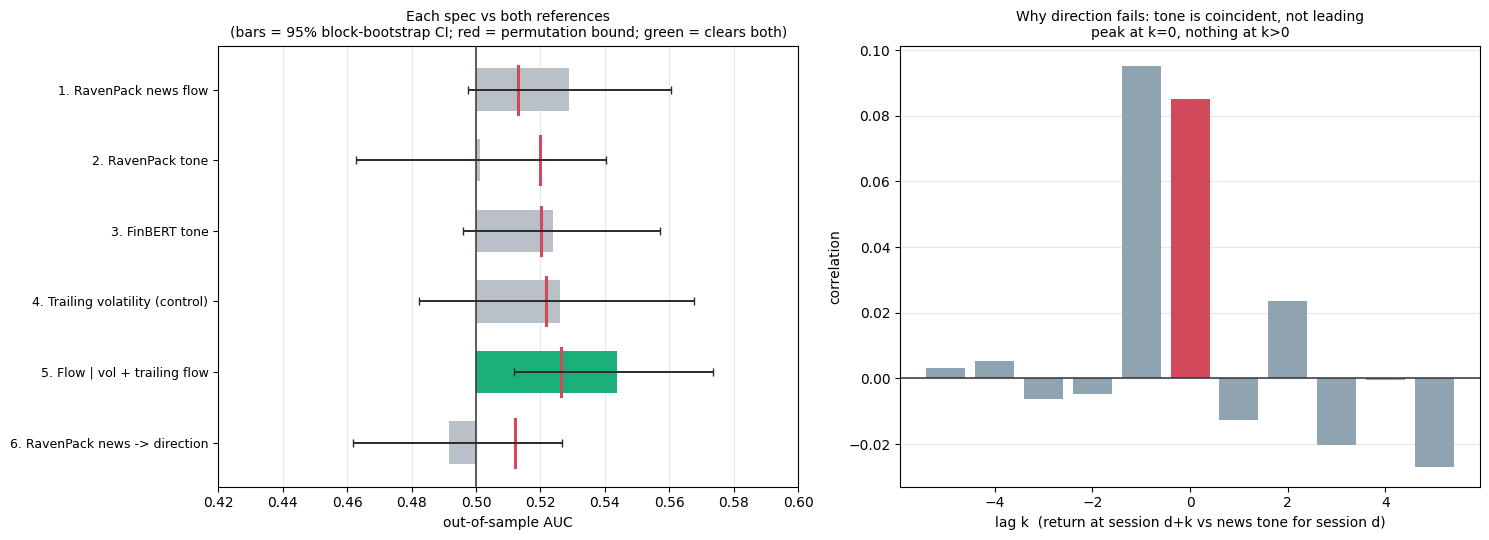

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- panel A: each spec against its own noise band ---
ax = axes[0]
order = results_df.iloc[::-1].reset_index(drop=True)
ypos = np.arange(len(order))
colors = ["#1baf7a" if c else "#b9c0c8" for c in order["clears_both"]]
ax.barh(ypos, order["auc_with_news"] - 0.5, left=0.5, color=colors, height=0.6, zorder=2)
ax.errorbar(order["auc_with_news"], ypos,
            xerr=[order["auc_with_news"] - order["auc_ci_low"],
                  order["auc_ci_high"] - order["auc_with_news"]],
            fmt="none", ecolor="#2b2b2b", elinewidth=1.4, capsize=3, zorder=5)
for k, row in order.iterrows():
    bound = row["detectable_bound"]
    ax.plot([bound, bound], [k - 0.34, k + 0.34], color="#d1495b", lw=2.2, zorder=3)
ax.axvline(0.5, color="#333", lw=1.1, zorder=4)
ax.set_yticks(ypos); ax.set_yticklabels(order["spec"], fontsize=9)
ax.set_xlabel("out-of-sample AUC")
ax.set_title("Each spec vs both references\n"
             "(bars = 95% block-bootstrap CI; red = permutation bound; "
             "green = clears both)", fontsize=10)
ax.set_xlim(min(0.42, order["auc_ci_low"].min() - 0.02),
            max(0.60, order["detectable_bound"].max() + 0.02))
ax.grid(axis="x", alpha=0.3, zorder=0)

# --- panel B: the mechanism -- tone is coincident, not leading ---
ax = axes[1]
lags = range(-5, 6)
tone = df["rp_tone"]
corrs = [tone.corr(df["r"].shift(-k)) for k in lags]
bar_colors = ["#d1495b" if k == 0 else "#8fa3b0" for k in lags]
ax.bar(list(lags), corrs, color=bar_colors, zorder=2)
ax.axhline(0, color="#333", lw=1.1)
ax.set_xlabel("lag k  (return at session d+k vs news tone for session d)")
ax.set_ylabel("correlation")
ax.set_title("Why direction fails: tone is coincident, not leading\n"
             "peak at k=0, nothing at k>0", fontsize=10)
ax.grid(axis="y", alpha=0.3, zorder=0)

plt.tight_layout()
fig_path = OUT_DIR / "news_flow_magnitude_summary.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {fig_path}")
plt.show()

### Handoff- `outputs/news_flow_magnitude_metrics.csv` — the full pre-registered grid with permutation  p-values and detectable-effect bounds.- `outputs/news_flow_magnitude_summary.png` — the two report figures.**Reading the result.** Specs 1 and 4 are the finding: news arrival volume and trailing volatilityeach predict the size of the next move out-of-sample, and each clears its own permutation null.Spec 5 is the honest qualifier — read it before quoting Spec 1. Spec 6 is the direction null thatnotebooks 05–10 found, reproduced on the corrected window so the two results sit on one axis.**Not claimed here.** Most of `close(d−1) → close(d)` is the overnight gap, which is not capturableby trading at the open. These are research findings about predictability, not a strategy. Splittinggap from open→close requires `dlyopen` from `crsp.dsf_v2`, which the current extract does not pull.